In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv("02-2024.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,46680396876,2024-02-01 09:07,NaN,00:00:43,NaN,David Valdez
1,46680733979,2024-02-01 09:08,NaN,00:05:15,NaN,David Valdez
2,46680924530,2024-02-01 09:08,NaN,00:01:12,NaN,Robin Stoehr
3,46680231347,2024-02-01 09:10,Outbound,00:06:05,NaN,Robin Stoehr
4,46681221688,2024-02-01 09:16,NaN,00:06:28,NaN,Robin Stoehr


In [7]:
df1=df.drop(columns=['hs_call_outcome','Record ID'])

In [9]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10878 entries, 0 to 10877
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         10878 non-null  str  
 1   Call direction        4516 non-null   str  
 2   Call duration         10545 non-null  str  
 3   Activity assigned to  10782 non-null  str  
dtypes: str(4)
memory usage: 757.0 KB


In [11]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors = "coerce"
)

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10878 entries, 0 to 10877
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10878 non-null  datetime64[us]
 1   Call direction        4516 non-null   str           
 2   Call duration         10545 non-null  str           
 3   Activity assigned to  10782 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 587.0 KB


# Call Count per day

In [16]:
df2 = df1.copy()

In [18]:
df2['date'] = df2['Activity date'].dt.date

In [20]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-02-01 09:07:00,NaN,00:00:43,David Valdez,2024-02-01
1,2024-02-01 09:08:00,NaN,00:05:15,David Valdez,2024-02-01
2,2024-02-01 09:08:00,NaN,00:01:12,Robin Stoehr,2024-02-01
3,2024-02-01 09:10:00,Outbound,00:06:05,Robin Stoehr,2024-02-01
4,2024-02-01 09:16:00,NaN,00:06:28,Robin Stoehr,2024-02-01


In [22]:
daily_calls=(
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [24]:
daily_calls.head()

,date,call_count
0,2024-02-01,601
1,2024-02-02,508
2,2024-02-03,67
3,2024-02-04,34
4,2024-02-05,528


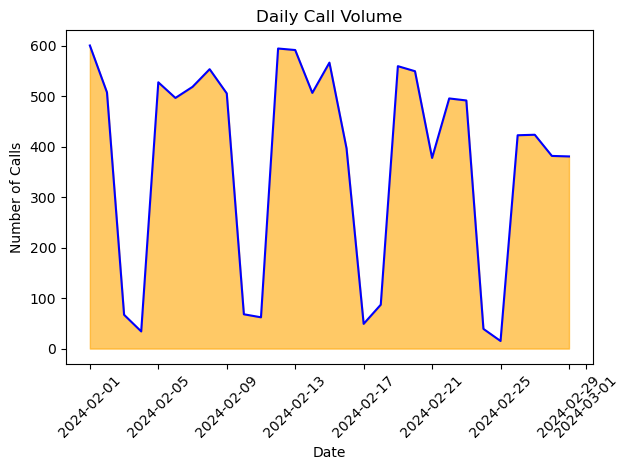

In [26]:
plt.figure()
plt.plot(daily_calls['date'],daily_calls['call_count'], color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [29]:
df1['day']=df1['Activity date'].dt.day_name()

In [31]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-02-01 09:07:00,NaN,00:00:43,David Valdez,Thursday
1,2024-02-01 09:08:00,NaN,00:05:15,David Valdez,Thursday
2,2024-02-01 09:08:00,NaN,00:01:12,Robin Stoehr,Thursday
3,2024-02-01 09:10:00,Outbound,00:06:05,Robin Stoehr,Thursday
4,2024-02-01 09:16:00,NaN,00:06:28,Robin Stoehr,Thursday


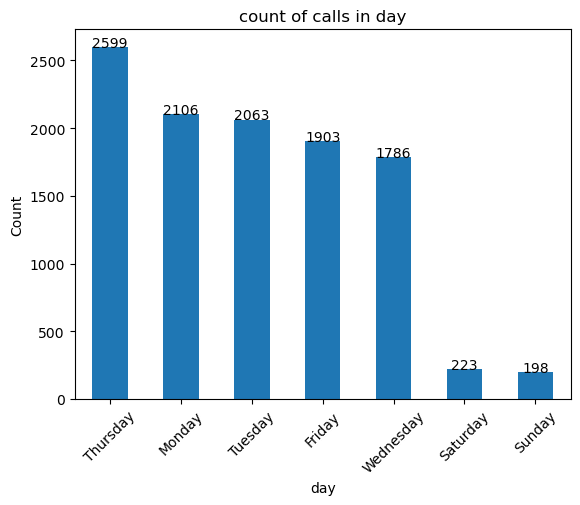

In [33]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

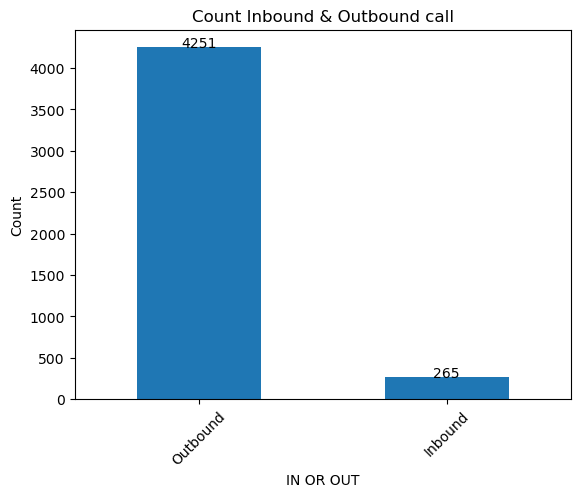

In [36]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [39]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

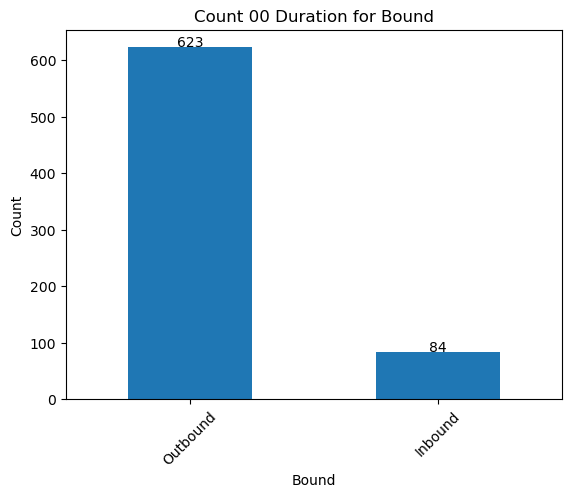

In [41]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction 

In [44]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
9,2024-02-01 09:40:00,Outbound,NaN,Robin Stoehr,Thursday
111,2024-02-01 11:49:00,Inbound,NaN,Robin Stoehr,Thursday
125,2024-02-01 12:05:00,Inbound,NaN,Robin Stoehr,Thursday
223,2024-02-01 14:27:00,Inbound,NaN,Robin Stoehr,Thursday
601,2024-02-02 09:29:00,Inbound,NaN,Robin Stoehr,Friday
...,...,...,...,...,...
10185,2024-02-28 12:57:00,Inbound,NaN,Cameron Dudley,Wednesday
10326,2024-02-28 16:15:00,Inbound,NaN,Robin Stoehr,Wednesday
10694,2024-02-29 14:48:00,Outbound,NaN,Keith Antonio,Thursday
10728,2024-02-29 15:39:00,Outbound,NaN,Cameron Dudley,Thursday


In [46]:
df4 = df1.copy()

In [48]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [50]:
(df4['Call duration'] == 0).sum()

707

In [52]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10878 entries, 0 to 10877
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10878 non-null  datetime64[us]
 1   Call direction        4516 non-null   str           
 2   Call duration         10545 non-null  float64       
 3   Activity assigned to  10782 non-null  str           
 4   day                   10878 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 664.8 KB


In [54]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [56]:
df4 = df4.dropna(subset = ['Call direction'])

In [58]:
(df4['Call duration'] == 0).sum()

819

In [60]:
df4.info()

<class 'pandas.DataFrame'>
Index: 4516 entries, 3 to 10877
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         4516 non-null   datetime64[us]
 1   Call direction        4516 non-null   str           
 2   Call duration         4516 non-null   float64       
 3   Activity assigned to  4432 non-null   str           
 4   day                   4516 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 332.7 KB


# Working Call Assigner

In [63]:
df1['Activity assigned to'].nunique()

25

In [65]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[       'David Valdez',        'Robin Stoehr',         'Sal Berdayi',
      'Cameron Dudley',    'Vladimir Suparto',        'Karen Parker',
       'Oliver Martin',       'Sam Steindorf',       'Garrett Evans',
           'Juan Calo',        'Dioni Canega',         'Adrian Tran',
                   nan,         'Paol Guzman',         'Jinky Rance',
           'Terry Kim', 'Demmie Rose Tamonan',        'Louis Maciel',
          'Henry Good',        'Bill Goodwin',      'David Banister',
       'Keith Antonio',     'Adonis Baybayan',   'Brittany Digiulio',
        'Stephen Tarr',    'Chrystel Manabat']
Length: 26, dtype: str

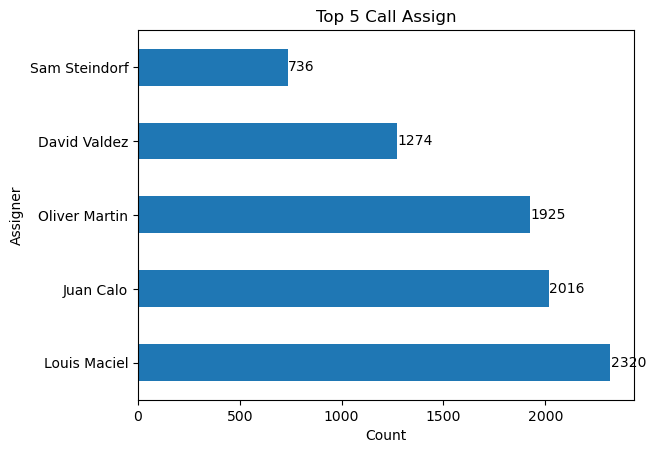

In [67]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [70]:
df4['Call duration'].max()

82.6

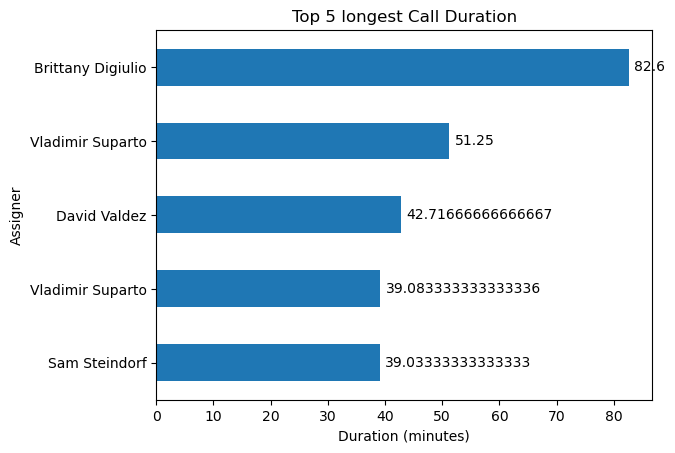

In [72]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [75]:
df3 = df1.copy()

In [77]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [79]:
df3['day'].unique()

<ArrowStringArray>
['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday']
Length: 5, dtype: str

In [81]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

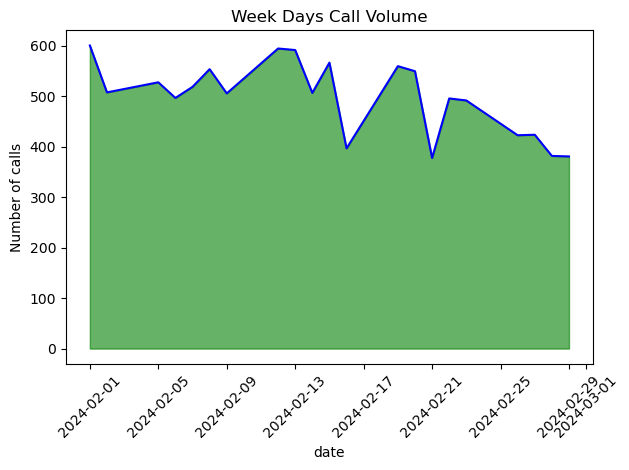

In [83]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [86]:
df5=df4.copy()

In [88]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [90]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
1176,2024-02-04 00:51:00,Inbound,0.000000,NaN,Sunday
6616,2024-02-17 13:16:00,Outbound,0.000000,Oliver Martin,Saturday
6617,2024-02-17 13:18:00,Outbound,1.066667,Oliver Martin,Saturday
6651,2024-02-18 08:20:00,Inbound,0.000000,NaN,Sunday
6659,2024-02-18 11:34:00,Outbound,0.000000,Robin Stoehr,Sunday


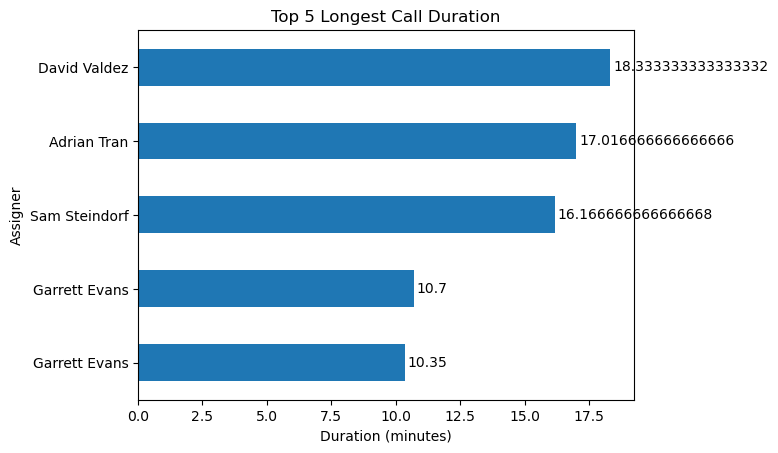

In [92]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

#  Top 5 Weekend Call Assigner

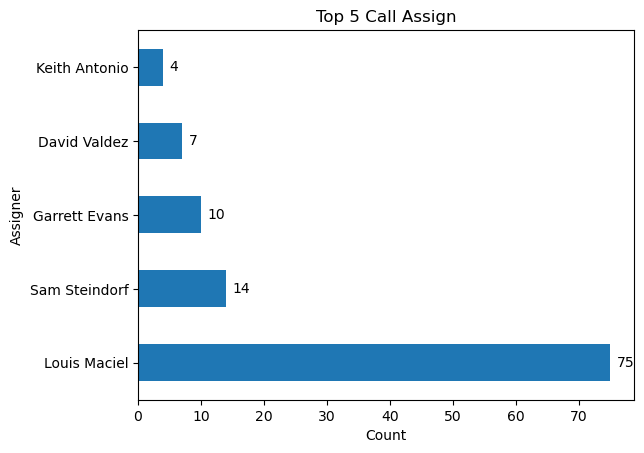

In [95]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [98]:
df4["Call duration"].mean()

1.5043733392382639

In [100]:
df4["Call duration"].median()

0.23333333333333334

# Without Call Assigner Calls 

In [103]:
df6 = df3.copy()

In [105]:
df6['month'] = df6['Activity date'].dt.month_name()

In [107]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

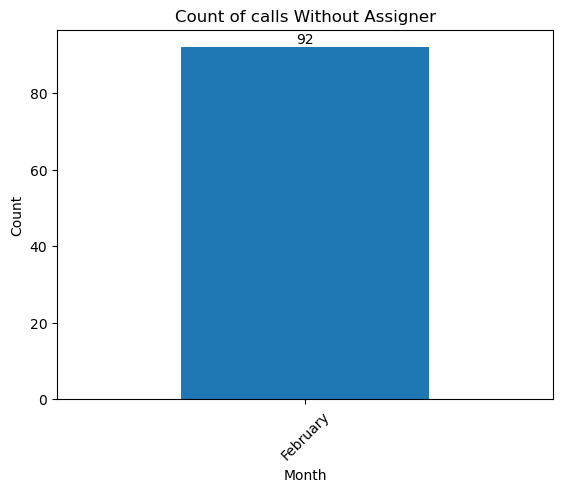

In [109]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call date

In [112]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [114]:
top5 = daily_calls.sort_values(ascending=False).head(5)

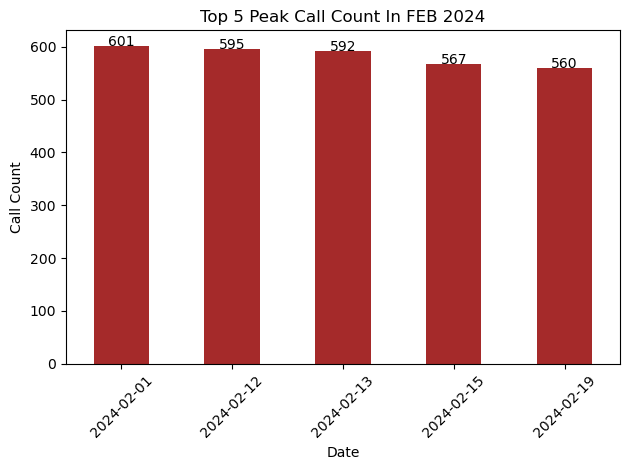

In [118]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In FEB 2024")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()